<a href="https://colab.research.google.com/github/vaishaliojha08-sys/FirstModel/blob/main/Ridge%26LassoRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ridge vs Lasso Regression – End-to-End Analysis

This notebook demonstrates a **comprehensive comparison of Linear Regression, Ridge, and Lasso**, focusing on:
- Overfitting behavior
- Effect of regularization (alpha)
- Feature selection differences
- Practical interpretation for real-world datasets


In [3]:
## Imports & Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import make_regression


In [4]:
np.random.seed(42)

X, y = make_regression(
    n_samples=800,
    n_features=30,
    n_informative=15,
    noise=10,
    random_state=42
)

# Add redundant features
X = np.column_stack([X, np.random.randn(800, 5)])


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train_scaled))
lr_test_r2 = r2_score(y_test, lr.predict(X_test_scaled))


In [7]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

ridge_train_r2 = r2_score(y_train, ridge.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge.predict(X_test_scaled))


In [8]:
lasso = Lasso(alpha=1.0, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_train_r2 = r2_score(y_train, lasso.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, lasso.predict(X_test_scaled))


In [9]:
ridge_gap = ridge_train_r2 - ridge_test_r2
lasso_gap = lasso_train_r2 - lasso_test_r2
baseline_gap = lr_train_r2 - lr_test_r2

In [10]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_train_scores = []
ridge_test_scores = []

for alpha in alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_scaled, y_train)

    ridge_train_scores.append(
        r2_score(y_train, model.predict(X_train_scaled))
    )
    ridge_test_scores.append(
        r2_score(y_test, model.predict(X_test_scaled))
    )


In [11]:
optimal_idx = np.argmax(ridge_test_scores)
optimal_alpha = alphas[optimal_idx]


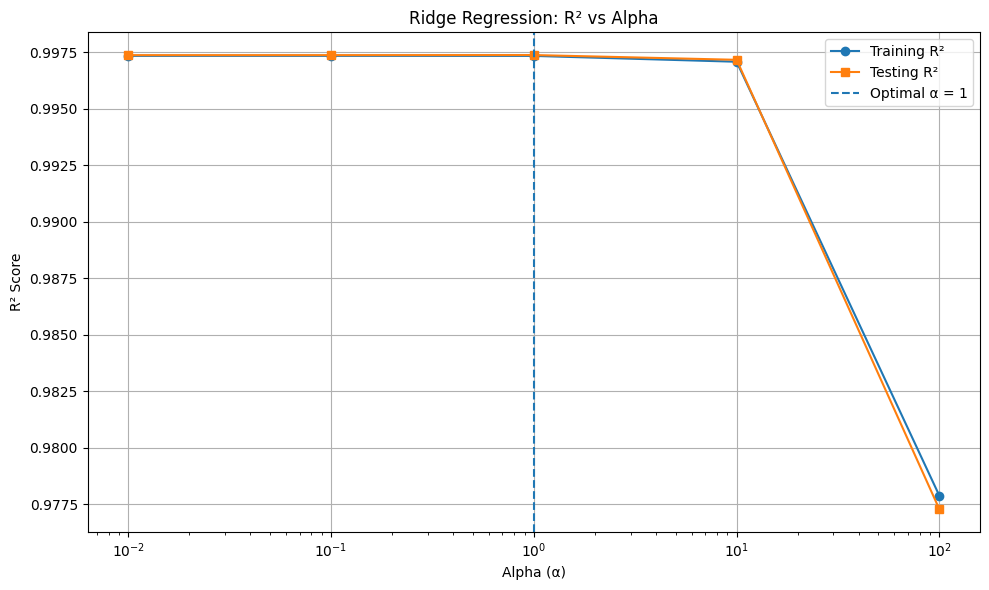

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_train_scores, 'o-', label='Training R²')
plt.plot(alphas, ridge_test_scores, 's-', label='Testing R²')
plt.axvline(optimal_alpha, linestyle='--', label=f'Optimal α = {optimal_alpha}')
plt.xscale('log')
plt.xlabel('Alpha (α)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: R² vs Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ridge_alpha_tuning.png')


In [13]:
ridge_final = Ridge(alpha=optimal_alpha, random_state=42)
ridge_final.fit(X_train_scaled, y_train)


Ridge(alpha=1, random_state=42)

In [14]:
lasso_alphas = [0.01, 0.1, 0.5, 1, 5, 10]
lasso_test_scores = []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)
    lasso_test_scores.append(
        r2_score(y_test, model.predict(X_test_scaled))
    )

optimal_lasso_alpha = lasso_alphas[np.argmax(lasso_test_scores)]


In [15]:
lasso_final = Lasso(
    alpha=optimal_lasso_alpha,
    max_iter=10000,
    random_state=42
)
lasso_final.fit(X_train_scaled, y_train)


Lasso(alpha=0.1, max_iter=10000, random_state=42)

In [16]:
ridge_nonzero = np.sum(np.abs(ridge_final.coef_) > 1e-10)
lasso_nonzero = np.sum(np.abs(lasso_final.coef_) > 1e-10)
